#  **Projet Prédiction Diabète — Sprint 1 : Livrable 1** 
## **Prétraitement & Analyse Exploratoire des Données (EDA)**



**Jeu de données :** `diabetes_012_health_indicators_BRFSS2015.csv` (BRFSS 2015)

**Objectif :** Construire un pipeline de prétraitement complet en vue de la modélisation.

---

### Plan du notebook

| # | Étape |
|---|-------|
| 0 | Imports & configuration |
| 1 | Chargement et compréhension initiale |
| 2 | Recodage de la variable cible |
| 3 | Séparation Target / Features |
| 4 | Typage des variables |
| 5 | Nettoyage (doublons & valeurs manquantes) |
| 6 | Scission Train / Validation / Test |
| 7 | Analyse exploratoire quantitative |
| 8 | Analyse exploratoire qualitative (EDA visuelle) |
| 9 | Normalisation |
| 10 | Sauvegarde des datasets nettoyés |

## **1. Configuration de l’environnement**

In [1]:
# Setup notebook environment
import sys
from pathlib import Path


# Add project root to Python path
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


print("Project root added to path:", PROJECT_ROOT)

Project root added to path: c:\Users\HAMZA OUBA\Desktop\diabetes-prediction-mlops


## **2. Import des bibliothèques**

In [2]:
# Standard libraries

# pandas est utilisé pour lire des fichiers (CSV, Excel…), trier, filtrer, modifier et faire des calculs sur les colonnes
import pandas as pd
# numpy est utilisé pour les calculs numériques, les tableaux et les opérations mathématiques
import numpy as np
# matplotlib est utilisé pour faire des graphiques
import matplotlib.pyplot as plt
# seaborn est comme matplotlib mais fait des graphiques plus jolis et plus simples que matplotlib
import seaborn as sns

# Project configuration
from src.config import RAW_DATA_FILE, TARGET_COLUMN

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})

# Data processing
from src.data.load_data import load_raw_dataset
from src.data.preprocessing import (
    recode_target_to_binary,
    split_features_target,
    cast_feature_types,
    clean_dataset,
)

from src.data.splitting import split_train_validation_test

# Visualization
from src.visualization.eda import (
    plot_target_distribution,
    plot_bmi_distribution_by_class,
    plot_binary_features_vs_target,
    plot_ordinal_boxplots,
    plot_age_diabetes_rate,
    plot_target_correlations,
    plot_correlation_matrix,
)

#scaling
from src.data.scaling import *

#saving
from src.data.save_data import save_processed_datasets

print("Imports successful")

Imports successful


## **3️. Chargement et Compréhension Initiale**

On utilise le fichier **`diabetes_012_health_indicators_BRFSS2015.csv`** car c'est le seul qui contient les 3 classes originales (0, 1, 2), ce qui correspond aux consignes du projet et permet d'effectuer le recodage binaire demandé.

Les deux autres fichiers ont été écartés pour les raisons suivantes :

- **`diabetes_binary_5050split_health_indicators_BRFSS2015`** a déjà subi un recodage incompatible avec les consignes : les classes prediabetes (1) et diabetes (2) ont été fusionnées sous la valeur 1, rendant impossible la distinction entre no diabetes et prediabetes. Il est donc impossible d'y appliquer le recodage demandé.
- **`diabetes_binary_health_indicators_BRFSS2015`** présente le même problème de recodage que le fichier précédent. Il souffre en plus d'un sous-échantillonnage artificiel qui équilibre les classes à 50/50, ce qui ne reflète pas la réalité de la distribution de la maladie dans la population. Utiliser ce fichier biaiserait l'analyse exploratoire et gonflerait artificiellement les métriques du modèle.

**`diabetes_012_health_indicators_BRFSS2015.csv`** est donc le seul fichier qui conserve l'information brute dans son état d'origine, avec les 3 classes distinctes nécessaires pour appliquer correctement le recodage prescrit dans les consignes.

In [3]:
# Load dataset
df_raw = load_raw_dataset(str(RAW_DATA_FILE))

print("Dataset shape:", df_raw.shape)

df_raw.head()

Dataset shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### **Types de données**

In [4]:
df_raw.dtypes

Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

### **Statistiques descriptives**

In [5]:
df_raw.describe().round(2)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,...,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00,253680.00
mean,0.3,0.43,0.42,0.96,28.38,0.44,0.04,0.09,0.76,0.63,...,0.95,0.08,2.51,3.18,4.24,0.17,0.44,8.03,5.05,6.05
std,0.7,0.49,0.49,0.19,6.61,0.50,0.20,0.29,0.43,0.48,...,0.22,0.28,1.07,7.41,8.72,0.37,0.50,3.05,0.99,2.07
min,0.0,0.00,0.00,0.00,12.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
25%,0.0,0.00,0.00,1.00,24.00,0.00,0.00,0.00,1.00,0.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00
50%,0.0,0.00,0.00,1.00,27.00,0.00,0.00,0.00,1.00,1.00,...,1.00,0.00,2.00,0.00,0.00,0.00,0.00,8.00,5.00,7.00
75%,0.0,1.00,1.00,1.00,31.00,1.00,0.00,0.00,1.00,1.00,...,1.00,0.00,3.00,2.00,3.00,0.00,1.00,10.00,6.00,8.00
max,2.0,1.00,1.00,1.00,98.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00


### **Distribution de la variable cible (3 classes originales)**

In [6]:
labels_orig = {0.0: 'No diabetes', 1.0: 'Prediabetes', 2.0: 'Diabetes'}
vc = df_raw[TARGET_COLUMN].value_counts().sort_index()
print("Target distribution:")
for label, count in vc.items():
    print(f"  {labels_orig.get(label, label)}: {count} ({count / len(df_raw) * 100:.2f}%)")



Target distribution:
  No diabetes: 213703 (84.24%)
  Prediabetes: 4631 (1.83%)
  Diabetes: 35346 (13.93%)


## **4️. Transformation de la variable cible**

**Rappel**

- 0 = No diabetes
- 1 = Prediabetes
- 2 = Diabetes

**Transformation demandée :**

- 0 → No diabetes + Prediabetes
- 1 → Diabetes


In [7]:
df = recode_target_to_binary(df_raw)

Distribution après recodage :

Binary target distribution
------------------------------------------------------------
Class 0 - No diabetes or Prediabetes: 218,334 (86.1%)
Class 1 - Diabetes: 35,346 (13.9%)


## **5. Séparation cible / variables explicatives**



In [8]:
X, y = split_features_target(df)

print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])
print("Variable cible : ", TARGET_COLUMN)
print('variable explicatives : ', X.columns.tolist())

Number of features: 21
Number of samples: 253680
Variable cible :  Diabetes_binary
variable explicatives :  ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


## **6️. Typage des variables**


In [9]:
X = cast_feature_types(X)

X.dtypes

HighBP                     int8
HighChol                   int8
CholCheck                  int8
BMI                     float32
Smoker                     int8
Stroke                     int8
HeartDiseaseorAttack       int8
PhysActivity               int8
Fruits                     int8
Veggies                    int8
HvyAlcoholConsump          int8
AnyHealthcare              int8
NoDocbcCost                int8
GenHlth                 float32
MentHlth                float32
PhysHlth                float32
DiffWalk                   int8
Sex                        int8
Age                     float32
Education               float32
Income                  float32
dtype: object

On distingue 3 catégories :
- **Variables binaires (14)** : réponses 0/1 → `int8`
- **Variables ordinales (6)** : échelles catégorielles ordonnées → `float32`
- **Variable continue (1)** : BMI → `float32`

## **7️. Nettoyage : Doublons & Valeurs Manquantes**



Dataset cleaning report
------------------------------------------------------------
Initial shape: (253680, 22)


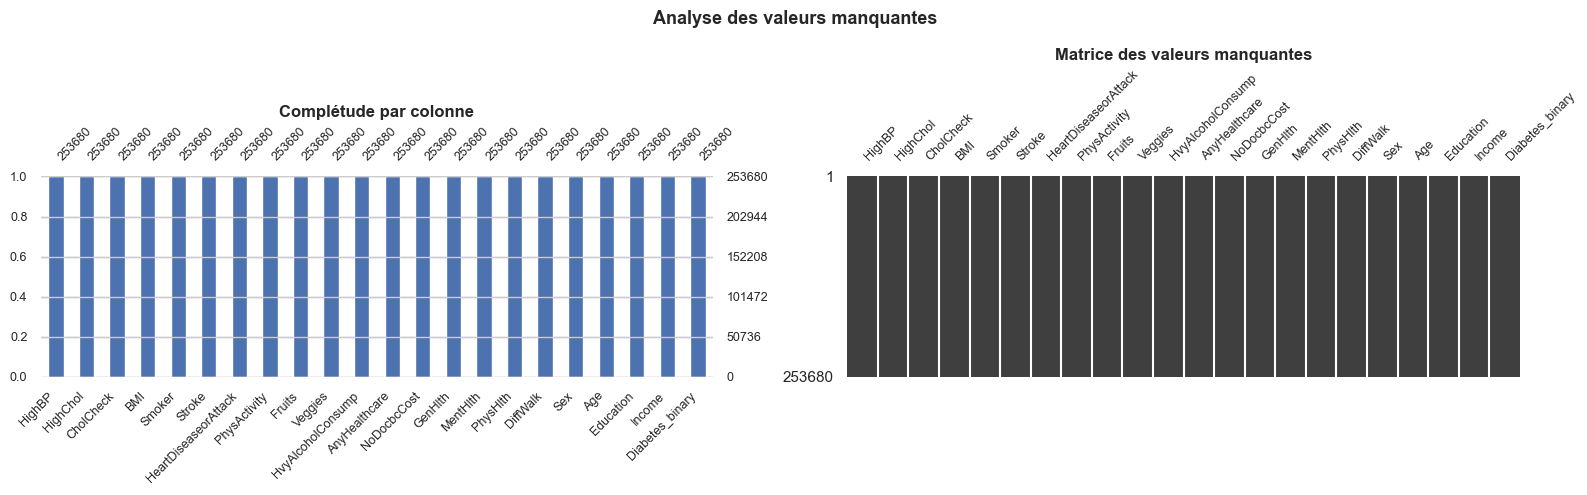

No missing values detected.

Duplicate rows report
------------------------------------------------------------
Detected duplicates: 24,206
Removed duplicates: 24,206
Final dataset shape: (229474, 22)


In [10]:
X_clean, y_clean = clean_dataset(X, y)

## **8️. Découpage des données : entraînement / validation / test**

Split **stratifié** pour conserver le ratio de classes dans chaque partition :
- **Train** : 70%
- **Validation** : 15%  
- **Test** : 15%


In [11]:
X_train, X_val, X_test, y_train, y_val, y_test = split_train_validation_test(
    X_clean,
    y_clean
)


Split          Lignes       %   Diabétiques    Taux
--------------------------------------------------
Train         160,631   70.0%        24,568   15.3%
Validation     34,421   15.0%         5,264   15.3%
Test           34,422   15.0%         5,265   15.3%


## **! Création d'un dataframe pour l'analyse :**

In [12]:
train_df = X_train.copy()
train_df[TARGET_COLUMN] = y_train.values

train_df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
132709,0,0,1,21.0,1,0,0,0,0,0,...,0,2.0,0.0,0.0,0,1,9.0,4.0,1.0,0
222350,1,1,1,23.0,1,1,0,1,1,1,...,0,4.0,15.0,30.0,1,1,10.0,4.0,2.0,0
118780,1,1,1,31.0,0,1,1,1,1,1,...,0,3.0,5.0,0.0,0,1,11.0,6.0,8.0,0
175633,0,1,1,31.0,0,0,0,1,1,0,...,0,3.0,0.0,0.0,0,1,9.0,6.0,8.0,0
178984,0,1,1,24.0,0,0,0,1,0,1,...,0,1.0,0.0,1.0,0,0,4.0,6.0,8.0,0


# **Analyse Exploratoire Quantitative**

### **Statistiques descriptives**

* mean = moyenne
* std = écart-type
* 25% = 1er quartile (Q1)
* 50% = médiane (Q2)
* 75% = 3e quartile (Q3)

In [ ]:
train_df = X_train.copy()
train_df[TARGET_COLUMN] = y_train.values

train_df.describe().round(2)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,160631.00,160631.00,160631.00,160631.00,160631.00,160631.00,160631.0,160631.00,160631.00,160631.00,...,160631.00,160631.00,160631.00,160631.00,160631.00,160631.00,160631.00,160631.00,160631.00,160631.00
mean,0.45,0.44,0.96,28.67,0.47,0.04,0.1,0.73,0.61,0.79,...,0.09,2.60,3.52,4.67,0.19,0.44,8.08,4.98,5.89,0.15
std,0.50,0.50,0.20,6.77,0.50,0.21,0.3,0.44,0.49,0.40,...,0.29,1.06,7.73,9.04,0.39,0.50,3.09,0.99,2.09,0.36
min,0.00,0.00,0.00,12.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00
25%,0.00,0.00,1.00,24.00,0.00,0.00,0.0,0.00,0.00,1.00,...,0.00,2.00,0.00,0.00,0.00,0.00,6.00,4.00,5.00,0.00
50%,0.00,0.00,1.00,27.00,0.00,0.00,0.0,1.00,1.00,1.00,...,0.00,3.00,0.00,0.00,0.00,0.00,8.00,5.00,6.00,0.00
75%,1.00,1.00,1.00,32.00,1.00,0.00,0.0,1.00,1.00,1.00,...,0.00,3.00,2.00,4.00,0.00,1.00,10.00,6.00,8.00,0.00
max,1.00,1.00,1.00,98.00,1.00,1.00,1.0,1.00,1.00,1.00,...,1.00,5.00,30.00,30.00,1.00,1.00,13.00,6.00,8.00,1.00


### **Corrélation des features avec la variable cible**

In [14]:
corr_target = train_df.corr()[TARGET_COLUMN].sort_values(ascending=False)
print("Corrélation avec Diabetes_binary (Pearson) :")
print(corr_target.round(3).to_string()) 

Corrélation avec Diabetes_binary (Pearson) :
Diabetes_binary         1.000
GenHlth                 0.275
HighBP                  0.255
DiffWalk                0.205
BMI                     0.204
HighChol                0.195
Age                     0.177
HeartDiseaseorAttack    0.169
PhysHlth                0.155
Stroke                  0.098
CholCheck               0.072
MentHlth                0.052
Smoker                  0.046
Sex                     0.032
AnyHealthcare           0.027
NoDocbcCost             0.017
Fruits                 -0.023
Veggies                -0.040
HvyAlcoholConsump      -0.065
Education              -0.100
PhysActivity           -0.101
Income                 -0.138


# **Analyse exploratoire (EDA)**

## **9. Distribution de la variable cible**


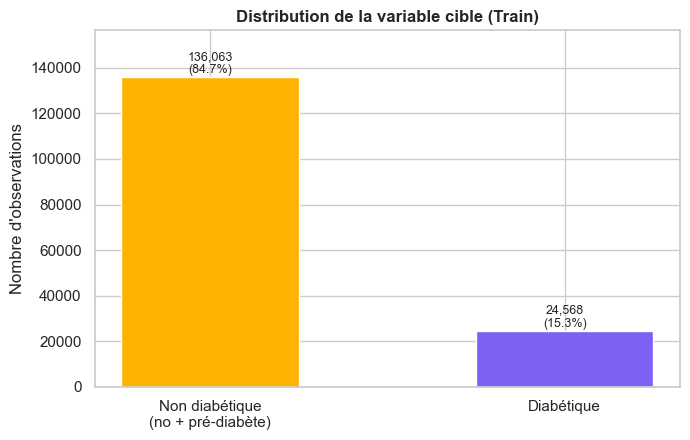

In [15]:
plot_target_distribution(train_df)

**Ce graphique montre :**

- la distribution de la classe cible

- un déséquilibre de classe important (~85% vs 15%)

**Ce point sera important pour :**

- la métrique ROC-AUC

- la gestion du class imbalance au Sprint 3

## **10. Distribution du BMI par classe**


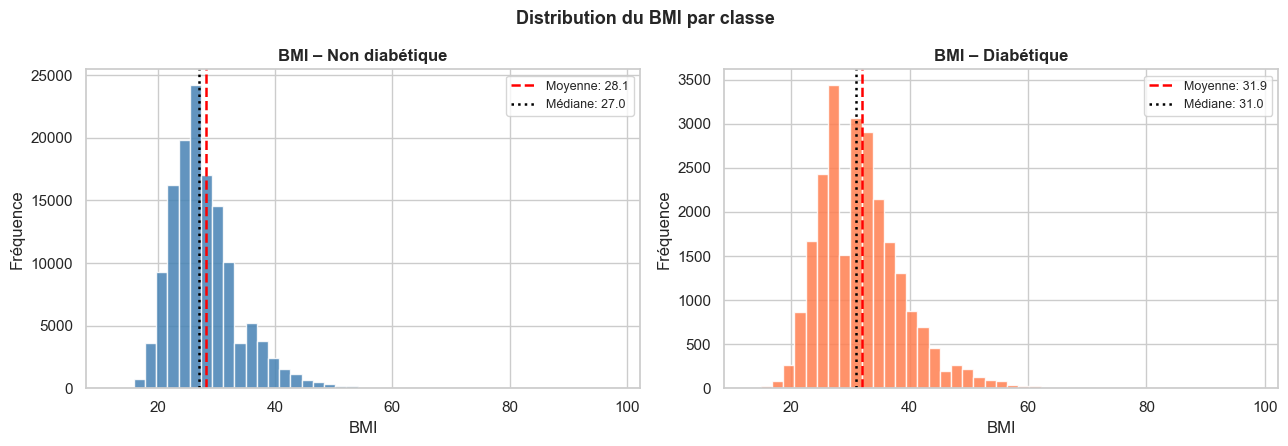

In [16]:
plot_bmi_distribution_by_class(train_df)

**Observation :**

- BMI moyen plus élevé chez les diabétiques

- distribution légèrement décalée vers la droite

- ***Le BMI semble donc être un facteur de risque important.***

## **11. Variables binaires vs diabète**


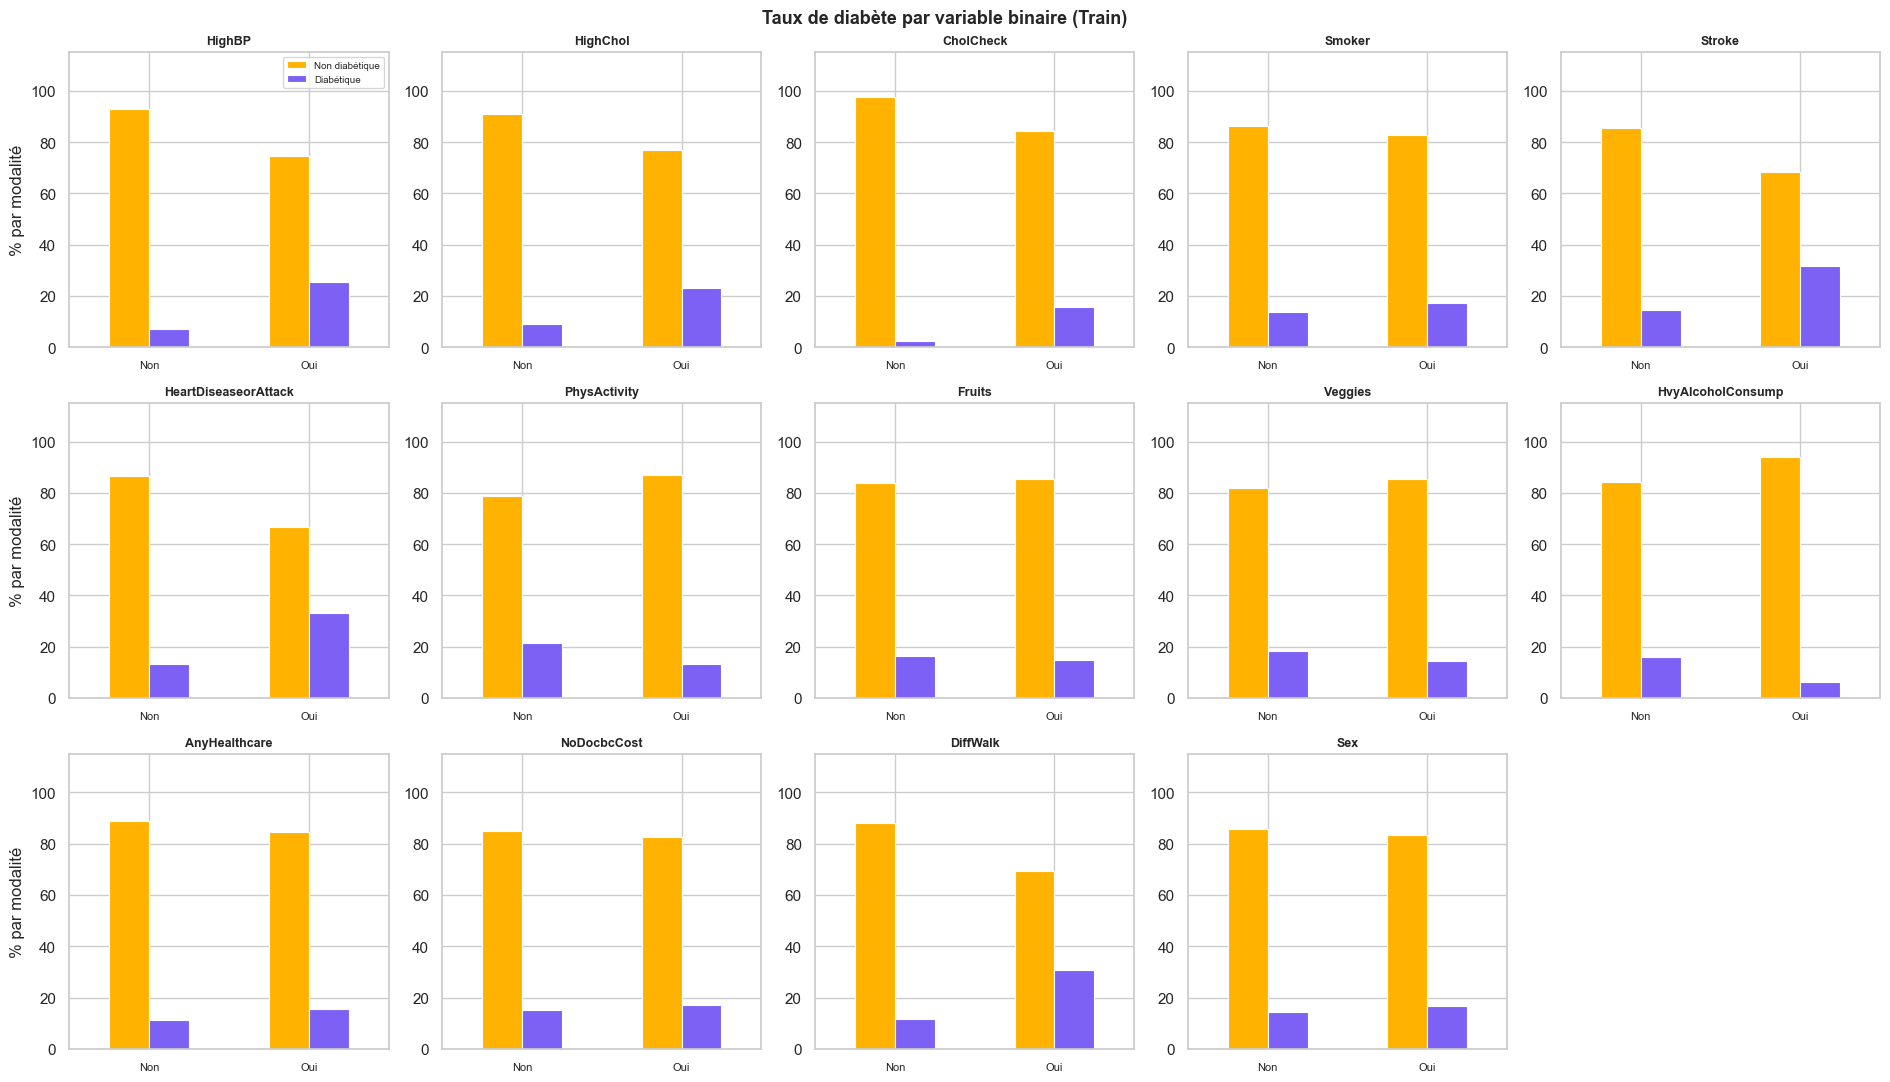

In [17]:
plot_binary_features_vs_target(train_df)

**Certaines variables ressortent fortement :**

- HighBP

- HighChol

- HeartDiseaseorAttack

- DiffWalk

***Ces variables sont fortement associées au diabète.***

## **12. Variables ordinales**


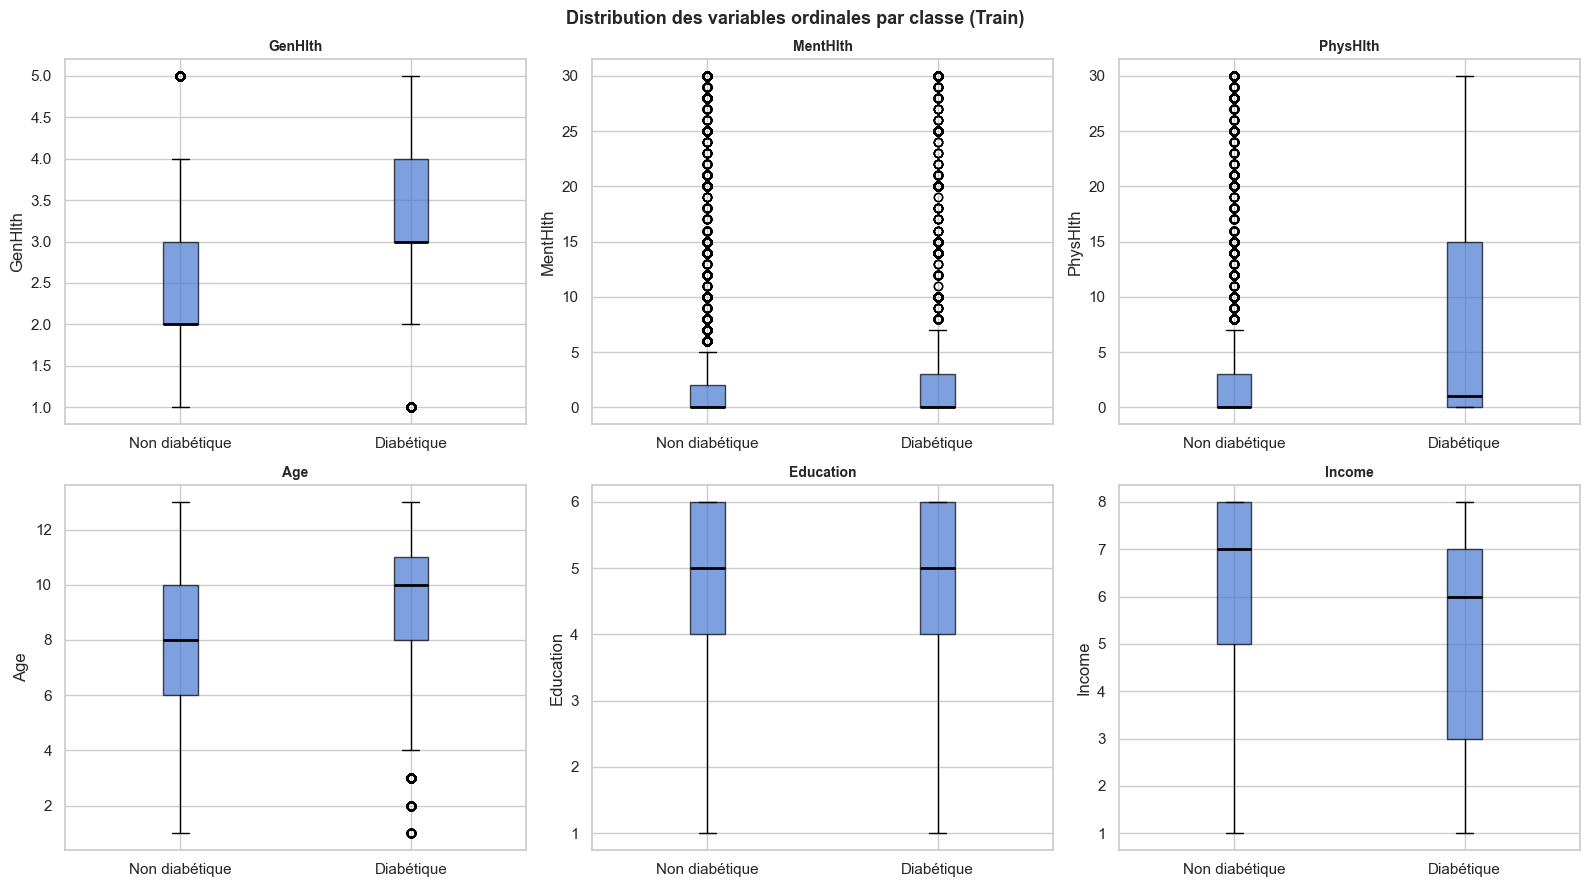

In [18]:
plot_ordinal_boxplots(train_df)

**Observations principales :**

- Age plus élevé chez les diabétiques

- GenHlth plus mauvais chez les diabétiques

- PhysHlth plus élevé chez les diabétiques

## **13. Taux de diabète par âge**


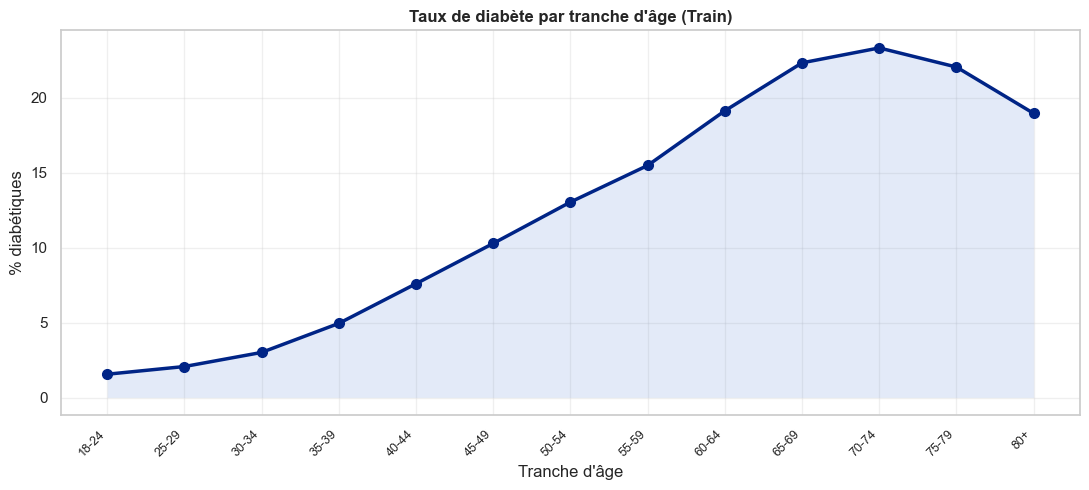

In [19]:
plot_age_diabetes_rate(train_df)

**Observation clé :**

- augmentation progressive du risque avec l'âge

- pic autour de 70–74 ans

## **14. Corrélation des variables avec la cible**


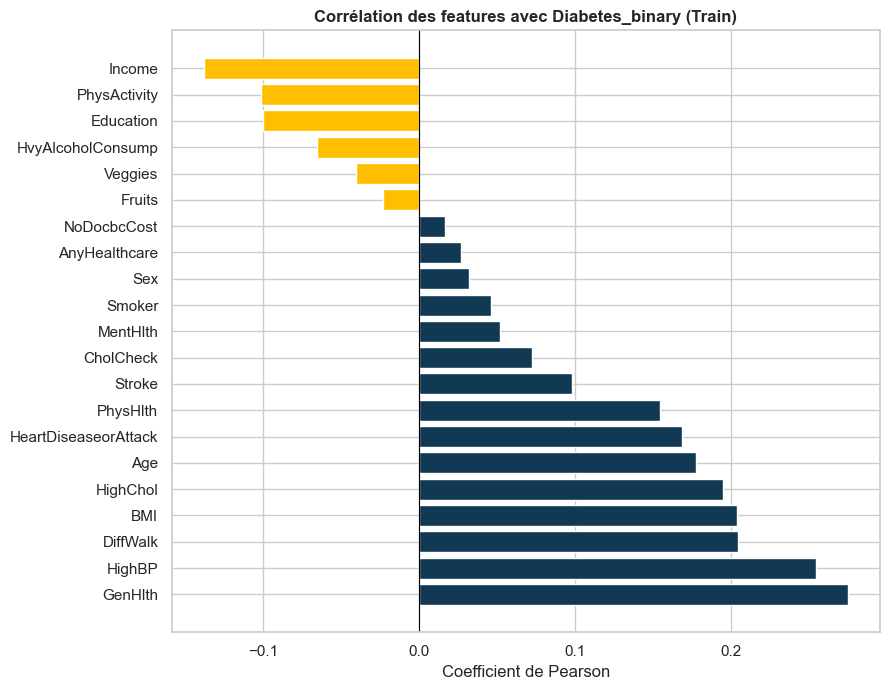

In [20]:
corr_target = plot_target_correlations(train_df)

**Variables les plus corrélées :**

**positivement :**

- GenHlth

- HighBP

- DiffWalk

- BMI

- HighChol

- Age

**négativement :**

- Income

- PhysActivity

- Education

Ces corrélations sont cohérentes avec la littérature médicale.

## **15. Matrice de corrélation**

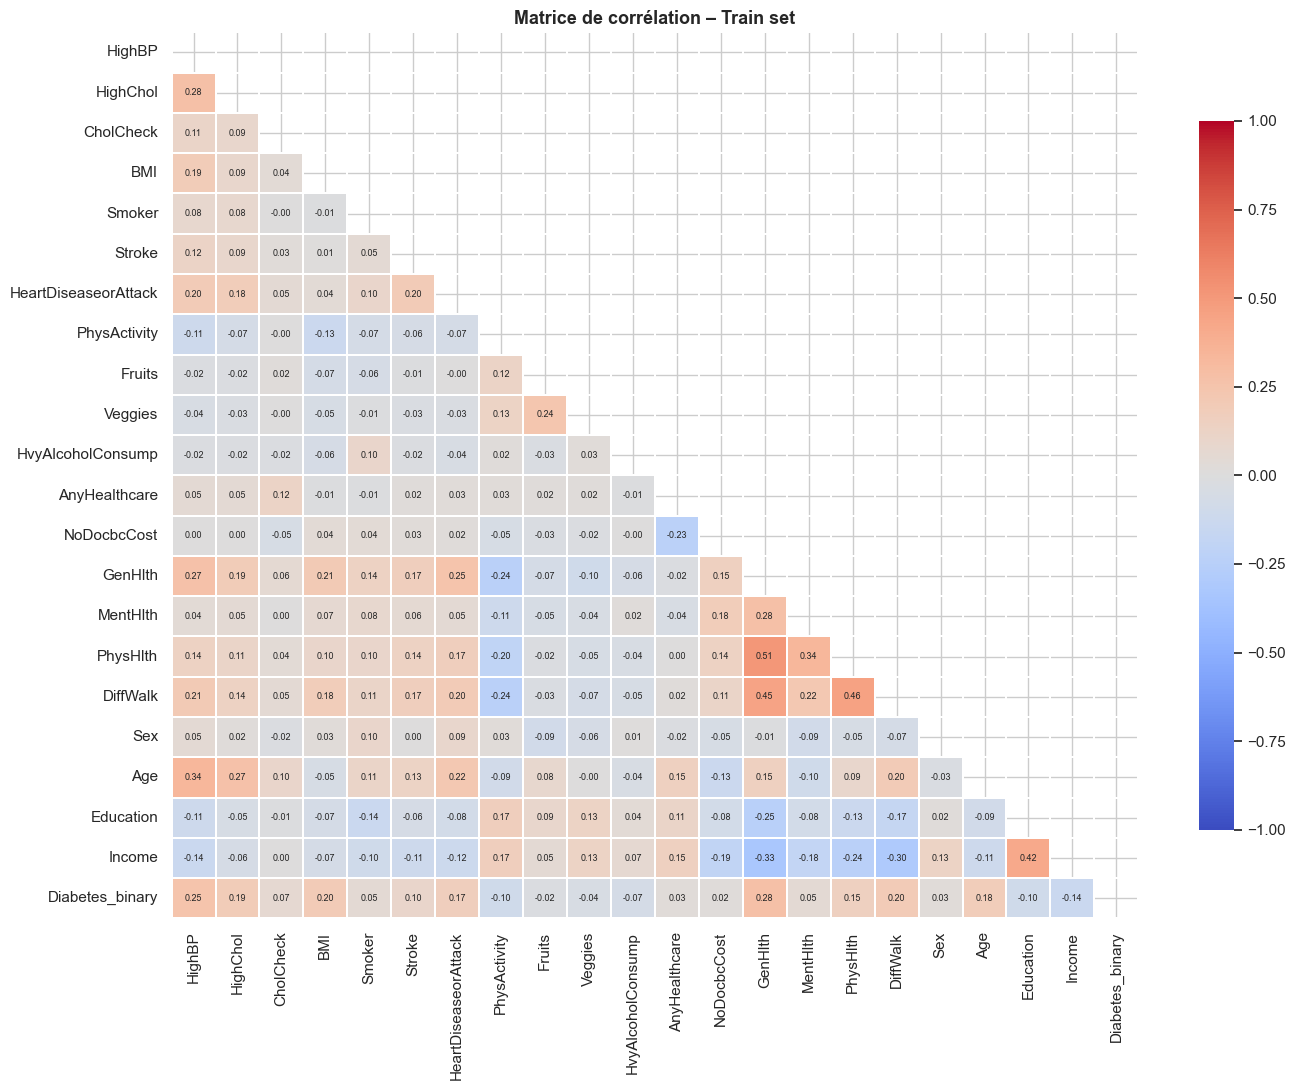

In [21]:
plot_correlation_matrix(train_df)

**Observation :**

- certaines corrélations entre variables existent

- mais aucune multicolinéarité extrême

**Par exemple :**

- PhysHlth ↔ DiffWalk

- GenHlth ↔ PhysHlth

# **Résumé EDA**


Principaux facteurs associés au diabète :

**Facteurs médicaux**

- HighBP

- HighChol

- HeartDisease

- BMI élevé

**Facteurs démographiques**

- âge

- revenu

- niveau d’éducation

**Facteurs comportementaux**

- activité physique

- alimentation

## **16. Normalisation**

Certaines variables numériques possèdent des **échelles différentes**.
Par exemple :

* `BMI` peut aller de **15 à 60**
* `MentHlth` et `PhysHlth` vont de **0 à 30**
* `Income` ou `Education` sont des **scores ordinales**

Pour éviter qu’une variable domine l’apprentissage du modèle, on applique une **normalisation Min-Max**.

La transformation utilisée est :


$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$


Ce qui ramène toutes les valeurs dans l’intervalle :


[0,1]




### **Règle fondamentale (éviter le data leakage)**

Le scaler doit être :

* **fit uniquement sur le train set**
* **transform appliqué sur validation et test**

Cela garantit que le modèle n’utilise **aucune information provenant des données futures**.


### **Variables normalisées**

Variables continues / ordinales :

```
BMI
MentHlth
PhysHlth
Age
GenHlth
Education
Income
```

Variables **binaires** :

```
HighBP
HighChol
Smoker
Stroke
HeartDiseaseorAttack
PhysActivity
Fruits
Veggies
HvyAlcoholConsump
AnyHealthcare
NoDocbcCost
DiffWalk
Sex
```

Elles sont déjà dans `[0,1]`, donc **pas besoin de scaling**.



In [22]:
cols_to_scale = [
    "BMI",
    "MentHlth",
    "PhysHlth",
    "Age",
    "GenHlth",
    "Education",
    "Income",
]

X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale_datasets(
    X_train,
    X_val,
    X_test,
    cols_to_scale,
)

### **Vérification du scaling**

On vérifie que les variables du train set sont bien dans l’intervalle [0,1].

In [23]:
print_scaling_summary(X_train_scaled, cols_to_scale)


Scaling summary on training set
------------------------------------------------------------
     BMI  MentHlth  PhysHlth  Age  GenHlth  Education  Income
min  0.0       0.0       0.0  0.0      0.0        0.0     0.0
max  1.0       1.0       1.0  1.0      1.0        1.0     1.0



## **17. Sauvegarde des datasets normalisés**


In [24]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"
save_processed_datasets(
    output_dir=OUTPUT_DIR,
    x_train=X_train_scaled,
    x_val=X_val_scaled,
    x_test=X_test_scaled,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    full_clean_dataset= pd.concat([X_clean, y_clean], axis=1)
)


Saved files
------------------------------------------------------------
- c:\Users\HAMZA OUBA\Desktop\diabetes-prediction-mlops\data\processed\train_cleaned.csv
- c:\Users\HAMZA OUBA\Desktop\diabetes-prediction-mlops\data\processed\val_cleaned.csv
- c:\Users\HAMZA OUBA\Desktop\diabetes-prediction-mlops\data\processed\test_cleaned.csv
- c:\Users\HAMZA OUBA\Desktop\diabetes-prediction-mlops\data\processed\dataset_cleaned_full.csv


### **Vérification rapide**

In [25]:
pd.read_csv(OUTPUT_DIR / "train_cleaned.csv").head()


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0,0,1,0.104651,1,0,0,0,0,0,...,0,0.25,0.000000,0.000000,0,1,0.666667,0.6,0.000000,0
1,1,1,1,0.127907,1,1,0,1,1,1,...,0,0.75,0.500000,1.000000,1,1,0.750000,0.6,0.142857,0
2,1,1,1,0.220930,0,1,1,1,1,1,...,0,0.50,0.166667,0.000000,0,1,0.833333,1.0,1.000000,0
3,0,1,1,0.220930,0,0,0,1,1,0,...,0,0.50,0.000000,0.000000,0,1,0.666667,1.0,1.000000,0
4,0,1,1,0.139535,0,0,0,1,0,1,...,0,0.00,0.000000,0.033333,0,0,0.250000,1.0,1.000000,0


In [26]:
pd.read_csv(OUTPUT_DIR / "test_cleaned.csv").head()


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0,0,1,0.162791,0,0,0,1,1,1,...,0,0.00,0.000000,0.000000,1,1,1.000000,1.0,1.000000,0
1,1,1,1,0.174419,1,0,0,0,1,0,...,0,0.75,0.000000,1.000000,1,0,0.916667,0.6,0.571429,0
2,0,1,1,0.151163,0,0,0,1,1,1,...,0,0.75,0.266667,0.400000,1,0,0.416667,0.8,0.571429,0
3,0,0,1,0.255814,0,0,0,1,0,0,...,0,0.25,0.000000,0.066667,0,0,0.083333,0.8,0.714286,0
4,1,0,1,0.244186,1,0,0,1,0,1,...,1,0.75,0.000000,0.100000,1,1,0.083333,1.0,1.000000,0


In [27]:
pd.read_csv(OUTPUT_DIR / "val_cleaned.csv").head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,0,1,1,0.209302,0,0,0,1,1,1,...,0,0.25,0.000000,0.000000,0,0,0.833333,0.6,0.571429,0
1,0,0,1,0.406977,0,0,0,0,0,1,...,0,0.50,0.000000,0.000000,0,0,0.583333,0.6,0.571429,0
2,0,0,1,0.139535,0,0,0,1,1,0,...,0,0.00,0.000000,0.000000,0,1,0.083333,1.0,0.857143,0
3,1,1,1,0.139535,1,0,1,1,1,1,...,0,0.50,0.166667,0.333333,0,0,1.000000,0.4,0.142857,0
4,0,1,1,0.209302,0,0,0,1,1,1,...,0,0.25,1.000000,0.000000,0,0,0.750000,0.8,0.857143,0


## **Résumé — Livrable 1**

| Étape | Résultat |
|-------|----------|
| **Dataset source** | `diabetes_012` — 253 680 lignes × 22 colonnes |
| **Recodage cible** | {0,1} → 0 (no/pré-diabète) / {2} → 1 (diabète) |
| **Valeurs manquantes** | Aucune ✓ |
| **Doublons supprimés** | 24 206 |
| **Shape nettoyé** | 229 474 lignes |
| **Train / Val / Test** | 70% / 15% / 15% (stratifié) |
| **Taux diabétiques (train)** | ~15.3% → déséquilibre à traiter au Sprint 2 |
| **Normalisation** | MinMaxScaler [0,1] sur 7 variables — fit sur train uniquement |
| **Top features** (corrélation) | GenHlth, HighBP, BMI, DiffWalk, HighChol |
